# case study: GI

In [1]:
from utils_WF import *
from utils_GI import *

In [2]:
# read from GI-data

# labels (open reading frames) of the essential genes
genes = np.loadtxt('GI-data/genes.txt', dtype=str)

# raw GI network of the essential genes
E = np.load('GI-data/E.npy')
E = 0.5 * (E + E.T)

# edge-level noise variance of the raw GI network of the essential genes
E_var = np.load('GI-data/E_var.npy')
E_var = 0.5 * (E_var + E_var.T)

In [3]:
# run the netWF algorithm to get the filtered GI network E_filtered
E_filtered = wiener_filter_iterative(E, E_var, directed=False, 
                                     solver='cg', rtol=1e-6, maxiter=5000)

In [4]:
# calculate the PSN of E_filtered
E_filtered_sim = calculate_profile_similarity(E_filtered)

In [5]:
np.save('GI-data/results/E_filtered_cg_sym.npy', E_filtered)
np.save('GI-data/results/E_filtered_sim_cg_sym.npy', E_filtered_sim)

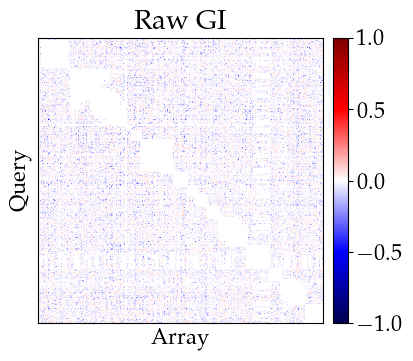

In [6]:
# plot the raw GI network

plot_gi(E, 'Raw GI', save=True)

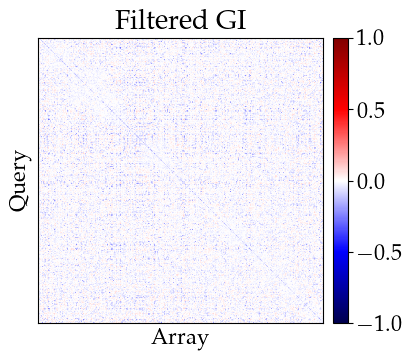

In [7]:
# plot the filtered GI network

plot_gi(E_filtered, 'Filtered GI', save=True)

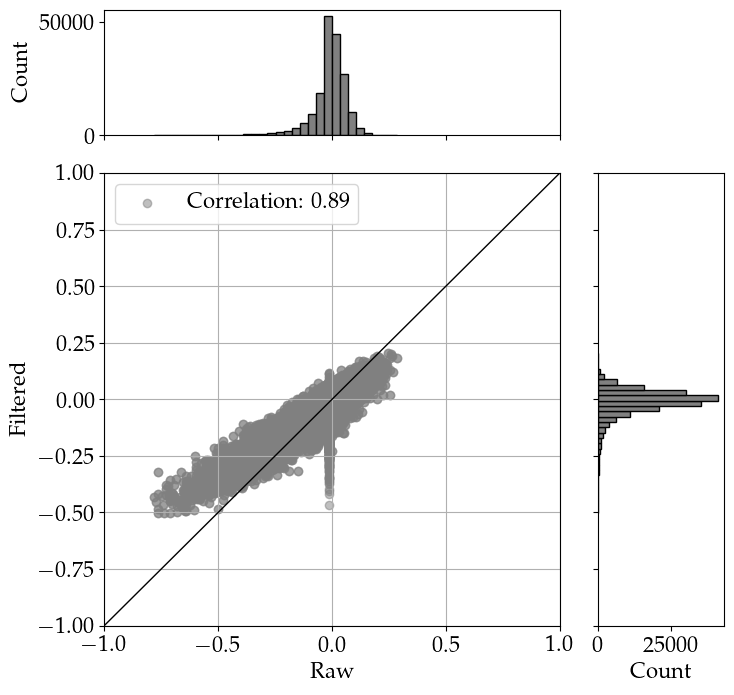

In [8]:
# plot the correlation between the raw and filtered GI entries

plot_corr(E, E_filtered, 'Raw', 'Filtered', save=False)